In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import pandas as pd
import glob
import os
import xarray as xr
import rasterio as rio
from rasterio.mask import mask
from shapely.geometry import mapping
import geopandas as gpd
from pyproj import Proj

In [2]:
folder = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/field_data/'
os.listdir(folder)

['GrandMesa_boundary_UTM.prj',
 'Lidar_bcal_processed',
 'SNEX20_GM_SWE_SD_Lidar-GPR_20200201_v01.0.csv',
 'SNEX20_GM_SWE_SD_SnowDensity_20200201_v01.0.tif',
 '.DS_Store',
 'depth',
 'SNEX20_GM_Lidar_SD_20200201_20200202_v01.0.tif',
 'SnowEx20_SnowPits_GMIOP_Summary_Environment_2020_v01.csv',
 'SnowEx2020_SnowDepths_COGM_alldepths_v01_handmeasurements.csv',
 'density',
 'GrandMesa_WGS.prj',
 'GrandMesa_boundary_UTM.shp',
 'GrandMesa_WGS.dbf',
 'SNEX20_GIS_REF_GM_v01',
 'GrandMesa_boundary_UTM.shx',
 'GrandMesa_boundary_UTM.qmd',
 'Tate_results',
 'SNEX20_GM_SWE_SD_SWE_20200201_v01.0.tif',
 'SnowEx20_SnowPits_GMIOP_Summary_SWE_2020_v01.csv',
 'meterology',
 'SNEX20_GM_Lidar_SDsubset_20200201_20200202_v01.0.tif',
 'GrandMesa_WGS.qmd',
 'GrandMesa_WGS.shx',
 'GrandMesa_boundary_UTM.dbf',
 'GrandMesa_WGS.cpg',
 'GrandMesa_WGS.shp']

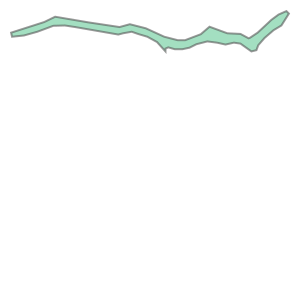

In [105]:
# read roads shapefile with geopandas
road_gdf = gpd.read_file(folder+'snowmobile_roads.shp')
geoms = road_gdf.geometry.values
road_geom = geoms[0] # grab the geometry 
road_x, road_y = road_geom.exterior.coords.xy
road_gdf = gpd.GeoDataFrame(crs='EPSG:32612', geometry=[road_geom]) # turn into geodataframe 
# road_gdf
road_geom

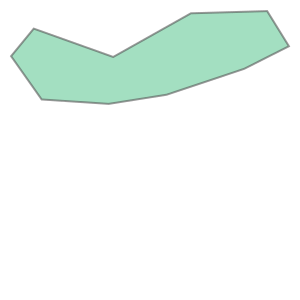

In [66]:
# read site shapefile with geopandas
site_gdf = gpd.read_file(folder+'GrandMesa_boundary_UTM.shp')
geoms = site_gdf.geometry.values
geom = geoms[0]
bounds_x, bounds_y = geom.exterior.coords.xy
# site_gdf
geom

## Read probed depths

37921


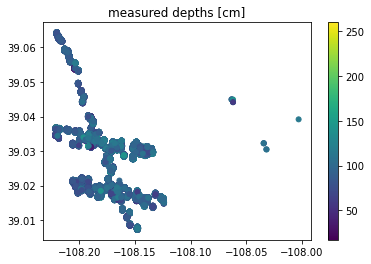

In [35]:
# grab measured depth data
depth_df = pd.read_csv(folder+'depth/SnowEx2020_SnowDepths_COGM_alldepths_v01_handmeasurements.csv')
# depth_df
print(len(depth_df))
plt.scatter(depth_df.Longitude,depth_df.Latitude,c=depth_df['Depth (cm)'],s=25)
# depth_df = depth_df[depth_df.Longitude < -108.10]
plt.title('measured depths [cm]')
plt.colorbar(); plt.show()

In [28]:
depth_df = depth_df.reset_index(drop=True)
depth_df

,Measurement Tool (MP = Magnaprobe; M2 = Mesa 2; PR = Pit Ruler),ID,Date (yyyymmdd),"Time (hh:mm, local, MST)",PitID,Longitude,Latitude,Easting,Northing,Depth (cm),elevation (m),equipment,Version Number
0,MP,100000,20200128,11:48,8N58,-108.13515,39.03045,747987.62,4324061.71,94,3148.200000,CRREL_B,1
1,MP,100001,20200128,11:48,8N58,-108.13516,39.03045,747986.75,4324061.68,74,3148.300000,CRREL_B,1
2,MP,100002,20200128,11:48,8N58,-108.13517,39.03045,747985.89,4324061.65,90,3148.200000,CRREL_B,1
3,MP,100003,20200128,11:48,8N58,-108.13519,39.03044,747984.19,4324060.49,87,3148.600000,CRREL_B,1
4,MP,100004,20200128,11:48,8N58,-108.13519,39.03042,747984.26,4324058.27,90,3150.100000,CRREL_B,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37903,PR,300162,20200204,13:40,5S29,-108.16532,39.01801,745419.00,4322599.00,110,3094.260010,ruler,1
37904,PR,300163,20200129,14:00,6S19,-108.18073,39.01846,744083.00,4322607.00,139,3051.560059,ruler,1
37905,PR,300164,20200211,15:04,1N5,-108.21137,39.03618,741369.00,4324492.00,88,3031.800049,ruler,1
37906,PR,300165,20200201,8:40,2S37,-108.15929,39.01926,745936.51,4322753.96,104,3102.780029,ruler,1


## Read in radar data

In [141]:
# grab radar daata
radaroutpath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/final_radar_picks/'
FMCW_processed = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/'
FMCW_results = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_wavelet_results/'

all_df = pd.read_csv(radaroutpath+'GM2020_rdpicks_all.csv')
all_df

,Unnamed: 0,x,y,Isurf,Iground,rd_xidx,TWT_surf,TWT_ground,rd_id,radar_depth_cm,lidar_depth,transect_name,collection_date,Unnamed: 0.1,Unnamed: 0.1.1
0,0,741911.781848,4.324354e+06,416.0,1168.0,141.0,4.225000e-09,1.186250e-08,rd01,85.196406,86.274414,1N6_5N10,20200128,NaN,NaN
1,1,741911.781848,4.324354e+06,416.0,1170.0,142.0,4.225000e-09,1.188281e-08,rd01,85.444219,86.274414,1N6_5N10,20200128,NaN,NaN
2,2,741911.781848,4.324354e+06,416.0,1171.0,143.0,4.225000e-09,1.189297e-08,rd01,85.568125,86.274414,1N6_5N10,20200128,NaN,NaN
3,3,741911.801295,4.324354e+06,416.0,1172.0,144.0,4.225000e-09,1.190313e-08,rd01,85.692031,86.274414,1N6_5N10,20200128,NaN,NaN
4,4,741911.801295,4.324354e+06,416.0,1174.0,145.0,4.225000e-09,1.192344e-08,rd01,85.939844,86.274414,1N6_5N10,20200128,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6677147,1267122,750191.547345,4.322257e+06,493.0,1312.0,3011.0,5.010040e-09,1.333301e-08,rd61,91.558179,113.520500,NorthLinee2,20200212,NaN,NaN
6677148,1267123,750191.569064,4.322258e+06,492.0,1312.0,3012.0,4.999878e-09,1.333301e-08,rd61,91.682159,113.520500,NorthLinee2,20200212,NaN,NaN
6677149,1267124,750191.569064,4.322258e+06,492.0,1312.0,3013.0,4.999878e-09,1.333301e-08,rd61,91.682159,113.520500,NorthLinee2,20200212,NaN,NaN
6677150,1267125,750191.569064,4.322258e+06,492.0,1312.0,3014.0,4.999878e-09,1.333301e-08,rd61,91.682159,114.399410,NorthLinee2,20200212,NaN,NaN


In [142]:
all_filtered_noNans = all_df.dropna(subset=['lidar_depth']) # prior to 1 to 1 plot, Nan lidars
all_filtered_noNans = all_filtered_noNans[all_filtered_noNans.lidar_depth > 0] # prior to 1 to 1 plot, 0 lidars
all_filtered_noNans = all_filtered_noNans.dropna(subset=['radar_depth_cm']) # prior to 1 to 1 plot, drop 0 lidars
all_filtered_noNans.reset_index(inplace=True)
all_filtered_noNans
# print(len(all_filtered_noNans))

,index,Unnamed: 0,x,y,Isurf,Iground,rd_xidx,TWT_surf,TWT_ground,rd_id,radar_depth_cm,lidar_depth,transect_name,collection_date,Unnamed: 0.1,Unnamed: 0.1.1
0,0,0,741911.781848,4.324354e+06,416.0,1168.0,141.0,4.225000e-09,1.186250e-08,rd01,85.196406,86.274414,1N6_5N10,20200128,NaN,NaN
1,1,1,741911.781848,4.324354e+06,416.0,1170.0,142.0,4.225000e-09,1.188281e-08,rd01,85.444219,86.274414,1N6_5N10,20200128,NaN,NaN
2,2,2,741911.781848,4.324354e+06,416.0,1171.0,143.0,4.225000e-09,1.189297e-08,rd01,85.568125,86.274414,1N6_5N10,20200128,NaN,NaN
3,3,3,741911.801295,4.324354e+06,416.0,1172.0,144.0,4.225000e-09,1.190313e-08,rd01,85.692031,86.274414,1N6_5N10,20200128,NaN,NaN
4,4,4,741911.801295,4.324354e+06,416.0,1174.0,145.0,4.225000e-09,1.192344e-08,rd01,85.939844,86.274414,1N6_5N10,20200128,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4261267,6677147,1267122,750191.547345,4.322257e+06,493.0,1312.0,3011.0,5.010040e-09,1.333301e-08,rd61,91.558179,113.520500,NorthLinee2,20200212,NaN,NaN
4261268,6677148,1267123,750191.569064,4.322258e+06,492.0,1312.0,3012.0,4.999878e-09,1.333301e-08,rd61,91.682159,113.520500,NorthLinee2,20200212,NaN,NaN
4261269,6677149,1267124,750191.569064,4.322258e+06,492.0,1312.0,3013.0,4.999878e-09,1.333301e-08,rd61,91.682159,113.520500,NorthLinee2,20200212,NaN,NaN
4261270,6677150,1267125,750191.569064,4.322258e+06,492.0,1312.0,3014.0,4.999878e-09,1.333301e-08,rd61,91.682159,114.399410,NorthLinee2,20200212,NaN,NaN


# Shift road data

In [87]:
# grab all data within road shapefile
radar_gpd = gpd.points_from_xy(all_filtered_noNans.x, all_filtered_noNans.y)
radar_gdf = gpd.GeoDataFrame(all_filtered_noNans, geometry=radar_gpd, crs='EPSG:32612')
points_within = gpd.sjoin(radar_gdf, road_gdf, predicate='within', how='inner') # spatial join
points_within

,index,Unnamed: 0,x,y,Isurf,Iground,rd_xidx,TWT_surf,TWT_ground,rd_id,radar_depth_cm,lidar_depth,transect_name,collection_date,Unnamed: 0.1,Unnamed: 0.1.1,geometry,index_right
13575,13645,13645,742071.527363,4.324307e+06,479.0,1358.0,2392.0,4.864844e-09,1.379219e-08,rd06,100.932500,98.920898,1N6_5N10,20200128,NaN,NaN,POINT (742071.527 4324306.797),0
13576,13646,13646,742071.527363,4.324307e+06,479.0,1357.0,2393.0,4.864844e-09,1.378203e-08,rd06,100.808594,98.920898,1N6_5N10,20200128,NaN,NaN,POINT (742071.527 4324306.797),0
13577,13647,13647,742071.527363,4.324307e+06,479.0,1356.0,2394.0,4.864844e-09,1.377188e-08,rd06,100.684687,98.920898,1N6_5N10,20200128,NaN,NaN,POINT (742071.527 4324306.797),0
13578,13648,13648,742071.527363,4.324307e+06,480.0,1355.0,2395.0,4.875000e-09,1.376172e-08,rd06,100.436875,98.920898,1N6_5N10,20200128,NaN,NaN,POINT (742071.527 4324306.797),0
13579,13649,13649,742071.546811,4.324307e+06,480.0,1354.0,2396.0,4.875000e-09,1.375156e-08,rd06,100.312969,98.920898,1N6_5N10,20200128,NaN,NaN,POINT (742071.547 4324306.791),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4138922,6537786,1127761,758499.115545,4.324854e+06,534.0,1201.0,1467.0,5.426697e-09,1.220499e-08,rd61,69.613593,137.299805,NorthLinee2,20200212,NaN,NaN,POINT (758499.116 4324854.008),0
4138923,6537787,1127762,758499.178406,4.324854e+06,534.0,1202.0,1468.0,5.426697e-09,1.221515e-08,rd61,69.737573,137.299805,NorthLinee2,20200212,NaN,NaN,POINT (758499.178 4324854.114),0
4138924,6537788,1127763,758499.178406,4.324854e+06,534.0,1202.0,1469.0,5.426697e-09,1.221515e-08,rd61,69.737573,137.299805,NorthLinee2,20200212,NaN,NaN,POINT (758499.178 4324854.114),0
4138925,6537789,1127764,758499.178406,4.324854e+06,535.0,1202.0,1470.0,5.436859e-09,1.221515e-08,rd61,69.613593,137.299805,NorthLinee2,20200212,NaN,NaN,POINT (758499.178 4324854.114),0


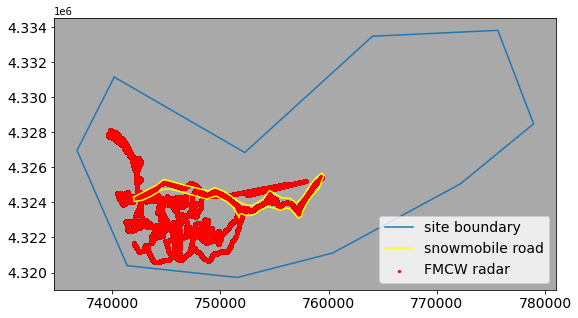

In [107]:
# plot overlap
fs = 14; a=1
fig, ax = plt.subplots(figsize=(9,5))
plt.plot(bounds_x, bounds_y, label='site boundary')
plt.plot(road_x, road_y, color='yellow',label='snowmobile road')
plt.scatter(all_df.x, all_df.y, color='red', label='FMCW radar', s=5, alpha=a) # radar points
plt.legend(fontsize=fs); plt.tick_params(labelsize=fs)
ax.set_facecolor('darkgrey'); ax.tick_params(labelsize=fs)
plt.show()

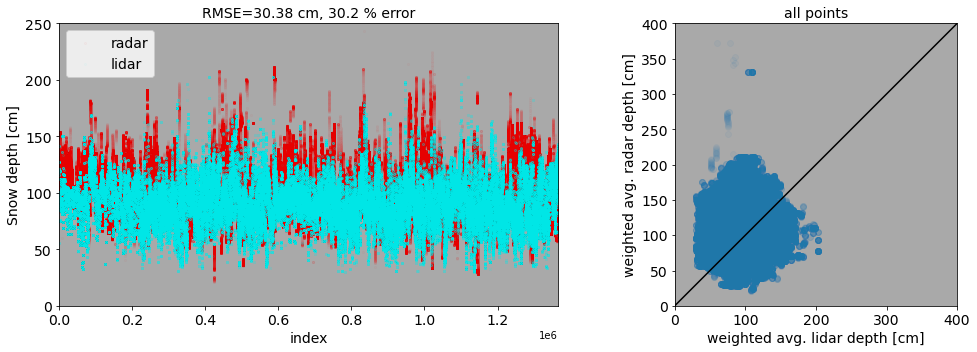

In [95]:
# compare lidar vs. radar 1 to 1 - plot
RMSE = np.round(np.sqrt(np.nanmean((np.array(points_within.radar_depth_cm) - np.array(points_within.lidar_depth))**2)),2)
percent_err = np.round(RMSE/np.nanmean(np.array(points_within.radar_depth_cm))*100,1)

# plot
fs = 14; a = 0.05; cs = 5; lw=2; ms=2; maxval = 400
fig, (ax,ax2) = plt.subplots(1,2,figsize=(15,5))
ax.scatter(range(0,len(points_within)), points_within.radar_depth_cm, marker='.',s=ms,
            color='red',linewidth=lw,label='radar',alpha=a) # radar
ax.scatter(range(0,len(points_within)), points_within.lidar_depth, marker='.',s=ms,
            color='cyan',linewidth=lw,label='lidar',alpha=a) # lidar
ax.legend(fontsize=fs,loc='upper left')
ax.set_ylabel('Snow depth [cm]',fontsize=fs); ax.set_xlabel('index', fontsize=fs)
ax.set_xlim(0,len(points_within)); ax.set_ylim(0,250)
ax.set_facecolor('darkgrey'); plt.grid(); ax.tick_params(labelsize=fs)
ax.set_title('RMSE='+str(RMSE)+' cm, '+str(percent_err)+' % error',fontsize=fs)

# 1 to 1 plot
minval=0
ax2.plot(points_within.lidar_depth, points_within.radar_depth_cm, 'o', alpha=a,label=window) # points
ax2.plot([minval,maxval],[minval,maxval],'k-') # 1 to 1 line
ax2.set_title('all points',fontsize=fs) # plot title
plt.gca().set_aspect('equal'); ax2.grid(); ax2.set_facecolor('darkgrey')
ax2.set_xlim(minval,maxval); ax2.set_ylim(minval,maxval); ax2.tick_params(labelsize=fs)
ax2.set_xlabel('weighted avg. lidar depth [cm]', fontsize=fs)
ax2.set_ylabel('weighted avg. radar depth [cm]', fontsize=fs)

plt.tight_layout()
# plt.savefig(radaroutpath+'depths_comparison_ground_'+str(window)+'m.jpg',dpi=200)
plt.show()

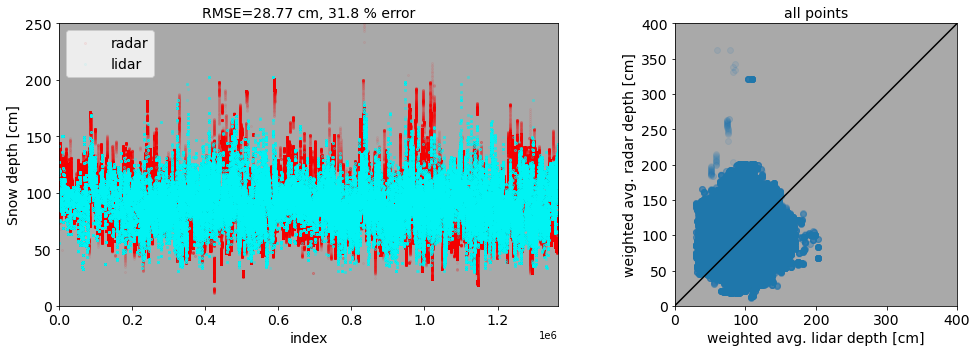

In [104]:
# compare lidar vs. radar on radargrams (load all rds)?
shifted_radar = np.array(points_within.radar_depth_cm) - 10

# compare lidar vs. radar 1 to 1 - plot
RMSE = np.round(np.sqrt(np.nanmean((shifted_radar - np.array(points_within.lidar_depth))**2)),2)
percent_err = np.round(RMSE/np.nanmean(shifted_radar)*100,1)

# plot
fs = 14; a = 0.1; cs = 5; lw=2; ms=2; maxval = 400
fig, (ax,ax2) = plt.subplots(1,2,figsize=(15,5))
ax.scatter(range(0,len(points_within)), shifted_radar, marker='.',s=ms,
            color='red',linewidth=lw,label='radar',alpha=a) # radar
ax.scatter(range(0,len(points_within)), points_within.lidar_depth, marker='.',s=ms,
            color='cyan',linewidth=lw,label='lidar',alpha=a) # lidar
ax.legend(fontsize=fs,loc='upper left')
ax.set_ylabel('Snow depth [cm]',fontsize=fs); ax.set_xlabel('index', fontsize=fs)
ax.set_xlim(0,len(points_within)); ax.set_ylim(0,250)
ax.set_facecolor('darkgrey'); plt.grid(); ax.tick_params(labelsize=fs)
ax.set_title('RMSE='+str(RMSE)+' cm, '+str(percent_err)+' % error',fontsize=fs)

# 1 to 1 plot
minval=0
ax2.plot(points_within.lidar_depth, shifted_radar, 'o', alpha=a,label=window) # points
ax2.plot([minval,maxval],[minval,maxval],'k-') # 1 to 1 line
ax2.set_title('all points',fontsize=fs) # plot title
plt.gca().set_aspect('equal'); ax2.grid(); ax2.set_facecolor('darkgrey')
ax2.set_xlim(minval,maxval); ax2.set_ylim(minval,maxval); ax2.tick_params(labelsize=fs)
ax2.set_xlabel('weighted avg. lidar depth [cm]', fontsize=fs)
ax2.set_ylabel('weighted avg. radar depth [cm]', fontsize=fs)

plt.tight_layout()
# plt.savefig(radaroutpath+'depths_comparison_ground_'+str(window)+'m.jpg',dpi=200)
plt.show()

200915715.316513


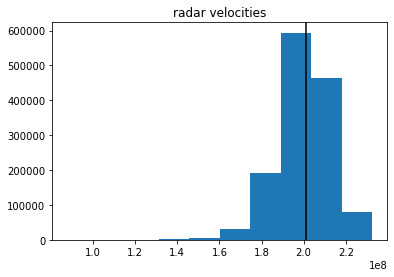

In [118]:
# find the linear shift that reduces the RMSE - 10cm
# calculate new velocity associated with shifted depth
adjusted_v = (shifted_radar/100)/(points_within.TWT_ground/2 - points_within.TWT_surf/2)
print(np.nanmedian(adjusted_v))
plt.hist(adjusted_v); plt.axvline(x=np.nanmedian(adjusted_v), color='k'); plt.title('radar velocities'); plt.show() # plot distribution

599.4503107749806
583.204562382101


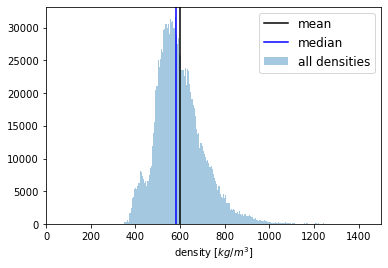

In [131]:
# calculate density associated with new velocity
# solve the quadratic equation for rho
a = 0.7
b = 1.7
c = 1-(3e8**2/(adjusted_v**2))
rho1 = (-b + np.sqrt((b**2)-4*a*c))/(2*a)
rho2 = (-b - np.sqrt((b**2)-4*a*c))/(2*a)

print(np.nanmean(rho1*1000));# multiply by 1000 to convert from g/cc to kg/m^3
print(np.nanmedian(rho1*1000));# multiply by 1000 to convert from g/cc to kg/m^3

# plot density distributions
fs = 12; a=0.4
fig, ax = plt.subplots(figsize=(6,4))
# ax.hist(rho2*1000,bins=50)
ax.hist(rho1*1000, bins=500,alpha=a) 
plt.axvline(x=np.nanmean(rho1*1000),color='k')
plt.axvline(x=np.nanmedian(rho1*1000),color='b')
ax.legend(['mean','median','all densities'],loc='upper right',fontsize=fs)
plt.xlim(0,1500); plt.xlabel('density [$kg/m^3$]')
plt.show()

In [133]:
all_filtered_noNans

,index,Unnamed: 0,x,y,Isurf,Iground,rd_xidx,TWT_surf,TWT_ground,rd_id,radar_depth_cm,lidar_depth,transect_name,collection_date,Unnamed: 0.1,Unnamed: 0.1.1,geometry
0,0,0,741911.781848,4.324354e+06,416.0,1168.0,141.0,4.225000e-09,1.186250e-08,rd01,85.196406,86.274414,1N6_5N10,20200128,NaN,NaN,POINT (741911.782 4324354.351)
1,1,1,741911.781848,4.324354e+06,416.0,1170.0,142.0,4.225000e-09,1.188281e-08,rd01,85.444219,86.274414,1N6_5N10,20200128,NaN,NaN,POINT (741911.782 4324354.351)
2,2,2,741911.781848,4.324354e+06,416.0,1171.0,143.0,4.225000e-09,1.189297e-08,rd01,85.568125,86.274414,1N6_5N10,20200128,NaN,NaN,POINT (741911.782 4324354.351)
3,3,3,741911.801295,4.324354e+06,416.0,1172.0,144.0,4.225000e-09,1.190313e-08,rd01,85.692031,86.274414,1N6_5N10,20200128,NaN,NaN,POINT (741911.801 4324354.345)
4,4,4,741911.801295,4.324354e+06,416.0,1174.0,145.0,4.225000e-09,1.192344e-08,rd01,85.939844,86.274414,1N6_5N10,20200128,NaN,NaN,POINT (741911.801 4324354.345)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4261267,6677147,1267122,750191.547345,4.322257e+06,493.0,1312.0,3011.0,5.010040e-09,1.333301e-08,rd61,91.558179,113.520500,NorthLinee2,20200212,NaN,NaN,POINT (750191.547 4322257.446)
4261268,6677148,1267123,750191.569064,4.322258e+06,492.0,1312.0,3012.0,4.999878e-09,1.333301e-08,rd61,91.682159,113.520500,NorthLinee2,20200212,NaN,NaN,POINT (750191.569 4322257.630)
4261269,6677149,1267124,750191.569064,4.322258e+06,492.0,1312.0,3013.0,4.999878e-09,1.333301e-08,rd61,91.682159,113.520500,NorthLinee2,20200212,NaN,NaN,POINT (750191.569 4322257.630)
4261270,6677150,1267125,750191.569064,4.322258e+06,492.0,1312.0,3014.0,4.999878e-09,1.333301e-08,rd61,91.682159,114.399410,NorthLinee2,20200212,NaN,NaN,POINT (750191.569 4322257.630)


In [139]:
shifted_radar

array([90.9325    , 90.80859375, 90.6846875 , ..., 59.73757324,
       59.61359253, 59.61359253])

In [144]:
all_filtered_noNans.loc[points_within.index].radar_depth_cm

13575      100.932500
13576      100.808594
13577      100.684687
13578      100.436875
13579      100.312969
              ...    
4138922     69.613593
4138923     69.737573
4138924     69.737573
4138925     69.613593
4138926     69.613593
Name: radar_depth_cm, Length: 1365545, dtype: float64

In [143]:
# add back into original dataframe
all_filtered_noNans.loc[points_within.index].radar_depth_cm = (points_within.TWT_ground/2 - points_within.TWT_surf/2)*np.nanmedian(adjusted_v)
all_filtered_noNans

,index,Unnamed: 0,x,y,Isurf,Iground,rd_xidx,TWT_surf,TWT_ground,rd_id,radar_depth_cm,lidar_depth,transect_name,collection_date,Unnamed: 0.1,Unnamed: 0.1.1
0,0,0,741911.781848,4.324354e+06,416.0,1168.0,141.0,4.225000e-09,1.186250e-08,rd01,85.196406,86.274414,1N6_5N10,20200128,NaN,NaN
1,1,1,741911.781848,4.324354e+06,416.0,1170.0,142.0,4.225000e-09,1.188281e-08,rd01,85.444219,86.274414,1N6_5N10,20200128,NaN,NaN
2,2,2,741911.781848,4.324354e+06,416.0,1171.0,143.0,4.225000e-09,1.189297e-08,rd01,85.568125,86.274414,1N6_5N10,20200128,NaN,NaN
3,3,3,741911.801295,4.324354e+06,416.0,1172.0,144.0,4.225000e-09,1.190313e-08,rd01,85.692031,86.274414,1N6_5N10,20200128,NaN,NaN
4,4,4,741911.801295,4.324354e+06,416.0,1174.0,145.0,4.225000e-09,1.192344e-08,rd01,85.939844,86.274414,1N6_5N10,20200128,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4261267,6677147,1267122,750191.547345,4.322257e+06,493.0,1312.0,3011.0,5.010040e-09,1.333301e-08,rd61,91.558179,113.520500,NorthLinee2,20200212,NaN,NaN
4261268,6677148,1267123,750191.569064,4.322258e+06,492.0,1312.0,3012.0,4.999878e-09,1.333301e-08,rd61,91.682159,113.520500,NorthLinee2,20200212,NaN,NaN
4261269,6677149,1267124,750191.569064,4.322258e+06,492.0,1312.0,3013.0,4.999878e-09,1.333301e-08,rd61,91.682159,113.520500,NorthLinee2,20200212,NaN,NaN
4261270,6677150,1267125,750191.569064,4.322258e+06,492.0,1312.0,3014.0,4.999878e-09,1.333301e-08,rd61,91.682159,114.399410,NorthLinee2,20200212,NaN,NaN


In [147]:
# save to new df:
all_filtered_noNans.to_csv(radaroutpath+'GM2020_rdpicks_all_roadadjusted.csv')

# Compare datasets

/Users/jukesliu/opt/anaconda3/envs/newautoriftenv/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


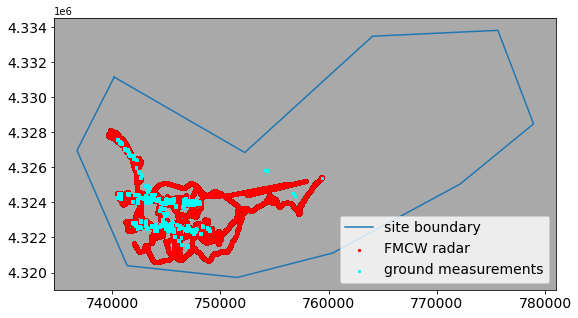

In [68]:
# plot overlap
fs = 14; a=1
fig, ax = plt.subplots(figsize=(9,5))
plt.plot(bounds_x, bounds_y, label='site boundary')
plt.scatter(all_df.x, all_df.y, color='red', label='FMCW radar', s=5, alpha=a)
plt.scatter(depth_df.Easting,depth_df.Northing,color='cyan',label='ground measurements',
            marker='s', s=7,alpha=a)
plt.legend(fontsize=fs); plt.tick_params(labelsize=fs)
ax.set_facecolor('darkgrey'); ax.tick_params(labelsize=fs)
plt.show()

In [148]:
from scipy.interpolate import interp1d
from sklearn.metrics import r2_score, mean_squared_error 

def weighted_avg(xpoints,ypoints,values,xarray,yarray,winsize):
    import numpy as np
    # calculated weighted average of the values at coordinates xarray,yarray within an N-meter radius of x0,y0
    # INPUTS:
    # xpoints = x-coordinate of the points at center of the window [m]
    # ypoints = y-coordinate of the point at center of the window [m]
    # values = values to average
    # xarray = x-coordinates of the values [m]
    # yarray = y-coordinates fo the values [m]
    # winsize = N-meter window (radius of circular window)
    # OUTPUTS:
    # mean_vals = list of weighted mean values
    # val_stds = list of std of values within each window
    
    sigma = winsize/2 
    mean_vals = []; val_stds = []
    for i in range(0, len(xpoints)):
        x0 = xpoints[i]; y0 = ypoints[i]
        
        # calculate distances to the point
        distance = euclidian_dist(x0,y0,xarray,yarray)
#         print(distance)
        weights = np.exp(-distance**2 / (2 * sigma**2))
        weighted_values = values*weights
        weighted_sum = np.nansum(weighted_values)

        if len(values) != len(weights):
            raise ValueError("Values and weights lists must have the same length.")

        sum_of_weights = np.nansum(weights)
        if sum_of_weights == 0:
#             raise ZeroDivisionError("Sum of weights cannot be zero.")
            mean_vals.append(np.NaN); val_stds.append(np.NaN) # add NaNs to lists
            continue
        mean_val = weighted_sum / sum_of_weights
        val_std = np.nanstd(weighted_values)
        
        if mean_val < -1000: # mean_val should never be this negative, this is to filter -inf division
            mean_val = np.NaN
        if val_std < -1000:
            val_std = np.NaN

        # add to lists
        mean_vals.append(mean_val); val_stds.append(val_std)
        
    return mean_vals, val_stds

def euclidian_dist(x1,y1,x2,y2):
    import numpy as np
    dist = np.sqrt((x2-x1)**2 + (y2-y1)**2)
    return dist

In [13]:
# all_filtered_noNans = all_df.dropna(subset=['lidar_depth']) # prior to 1 to 1 plot, drop 0 lidars
# all_filtered_noNans = all_filtered_noNans.dropna(subset=['radar_depth_cm']) # prior to 1 to 1 plot, drop 0 lidars
# all_filtered_noNans.reset_index(inplace=True)
# print(len(all_filtered_noNans))

4261819


In [209]:
# calculate radar average at field measurements of depth
window = 3

[radar_avg, radar_std] = weighted_avg(depth_df.Easting, depth_df.Northing, all_filtered_noNans.radar_depth_cm, 
             all_filtered_noNans.x, all_filtered_noNans.y, window)
# # interpolate the lidar data
# [measured_avg, measured_std] = weighted_avg(x_spaced, y_spaced, depth_df['Depth (cm)'], 
#              all_filtered_noNans.x, all_filtered_noNans.y, window)

In [ ]:
spaced_dist = range(0,len(depth_df))
# calculate RMSE and percent error
RMSE = np.round(np.sqrt(np.nanmean((np.array(radar_avg) - np.array(depth_df['Depth (cm)']))**2)),2)
percent_err = np.round(RMSE/np.nanmean(radar_avg)*100,1)

# plot snow depths along the transect
fs = 14; a = 0.1; cs = 5; lw=2; ms=2; maxval = 350
fig, (ax,ax2) = plt.subplots(1,2,figsize=(15,5))
ax.errorbar(spaced_dist, radar_avg, yerr=radar_std, marker='.',markersize=ms,
            color='red',linewidth=lw,label='radar',capsize=cs,alpha=a) # radar
ax.errorbar(spaced_dist, depth_df['Depth (cm)'], marker='.',markersize=ms, 
            color='cyan',linewidth=lw,label='measured',capsize=cs,alpha=a) # lidar
ax.legend(fontsize=fs,loc='upper left')
ax.set_ylabel('Snow depth [cm]',fontsize=fs); ax.set_xlabel('index', fontsize=fs)
ax.set_xlim(0,np.nanmax(spaced_dist)); ax.set_ylim(0,maxval)
ax.set_facecolor('darkgrey'); plt.grid(); ax.tick_params(labelsize=fs)
ax.set_title('RMSE='+str(RMSE)+' cm, '+str(percent_err)+' % error',fontsize=fs)

# 1 to 1 plot
minval=0
ax2.plot(depth_df['Depth (cm)'], radar_avg, 'o', alpha=a,label=window) # points
ax2.plot([minval,maxval],[minval,maxval],'k-') # 1 to 1 line
ax2.set_title(str(window)+' m window',fontsize=fs) # plot title
plt.gca().set_aspect('equal'); ax2.grid(); ax2.set_facecolor('darkgrey')
ax2.set_xlim(minval,maxval); ax2.set_ylim(minval,maxval); ax2.tick_params(labelsize=fs)
ax2.set_xlabel('weighted avg. measured depth [cm]', fontsize=fs)
ax2.set_ylabel('weighted avg. radar depth [cm]', fontsize=fs)

plt.tight_layout()
plt.savefig(radaroutpath+'depths_comparison_ground_roadadjusted_'+str(window)+'m.jpg',dpi=200)
plt.show()

# Geolocation shift of radar x,y up to +- 3m

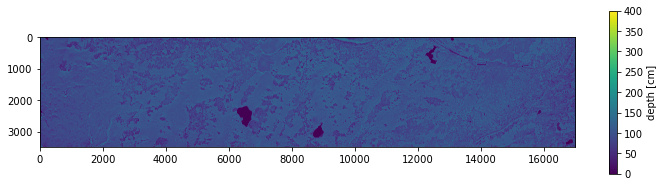

In [170]:
# grab the lidar data
# referencefile = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/field_data/depth/SnwDpth_Grnd_Asp_Slp_CPC_CHM_FHD512.tif'
referencefile = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/field_data/depth/SNEX20_GM_Lidar_SD_20200201_20200202_v01.0_UTM12.tif'
file = rio.open(referencefile)
# lidar_DATA = file.read(1) # read in the first and only band (elevations)
lidar_DATA = file.read(1)*100 # convert to cm
# create the 1-m grid centers
grid_X = np.arange(file.bounds.left+0.5, file.bounds.right,0.9997369)
grid_Y = np.arange(file.bounds.top-0.5,file.bounds.bottom,-0.9997369)
# # plot
plt.figure(figsize=(12,3)); plt.imshow(lidar_DATA, vmin=0, vmax=400);
cbar = plt.colorbar(); cbar.set_label('depth [cm]'); plt.show()

3.5 -3.0
extracting lidar data...
calculating r^2...


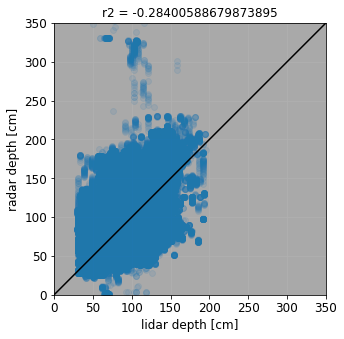

3.5 -2.5
extracting lidar data...
calculating r^2...


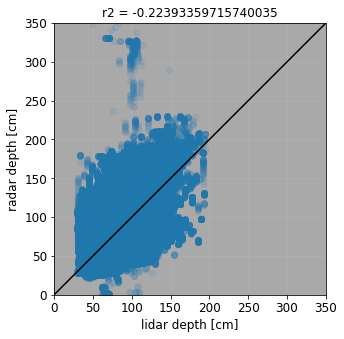

3.5 -2.0
extracting lidar data...
calculating r^2...


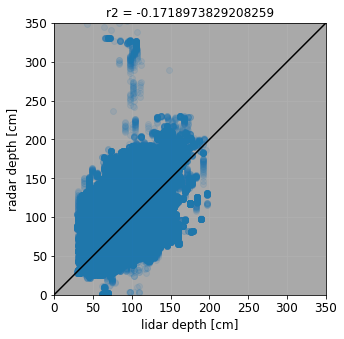

3.5 -1.5
extracting lidar data...
calculating r^2...


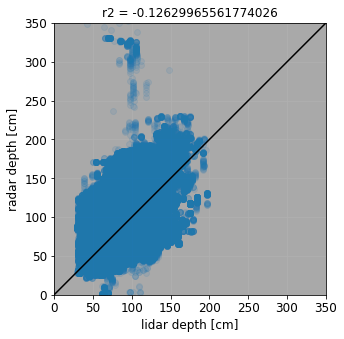

3.5 -1.0
extracting lidar data...
calculating r^2...


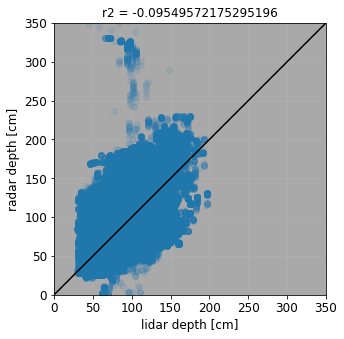

3.5 -0.5
extracting lidar data...
calculating r^2...


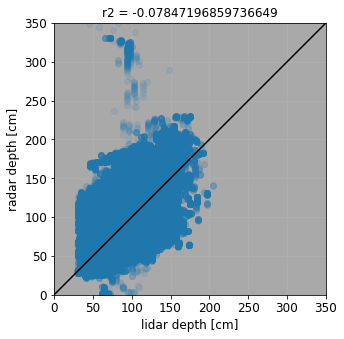

3.5 0.0
extracting lidar data...
calculating r^2...


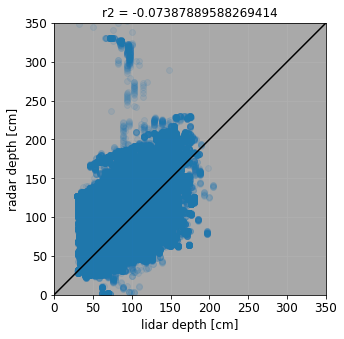

3.5 0.5
extracting lidar data...
calculating r^2...


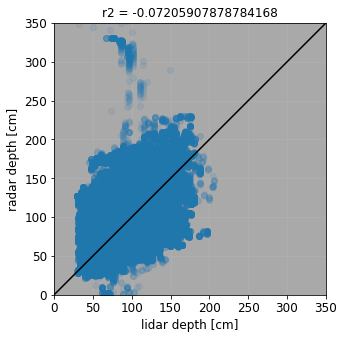

3.5 1.0
extracting lidar data...
calculating r^2...


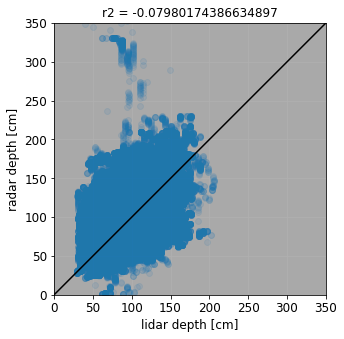

3.5 1.5
extracting lidar data...
calculating r^2...


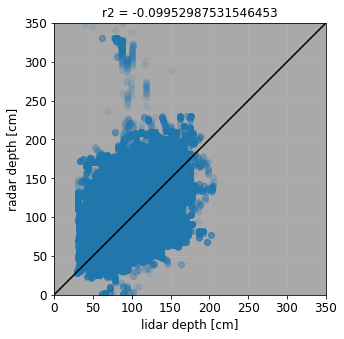

3.5 2.0
extracting lidar data...
calculating r^2...


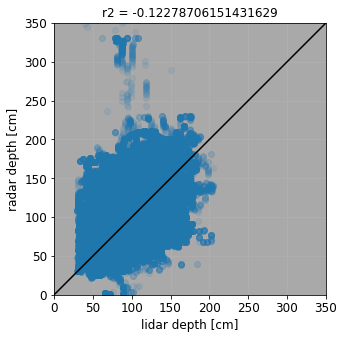

3.5 2.5
extracting lidar data...
calculating r^2...


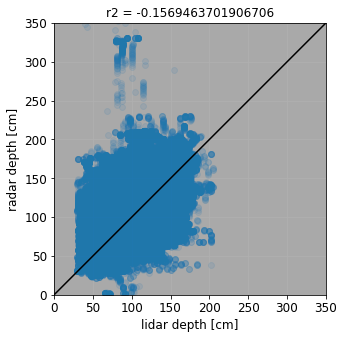

calculating r^2...


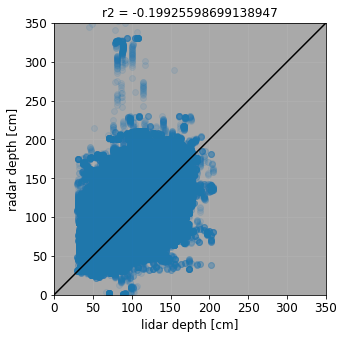

3.5 3.5
extracting lidar data...
calculating r^2...


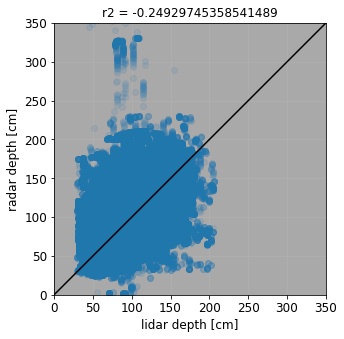

4.0 -3.0
extracting lidar data...
calculating r^2...


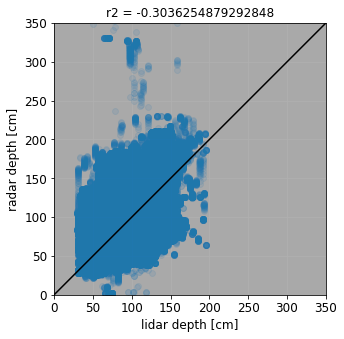

4.0 -2.5
extracting lidar data...
calculating r^2...


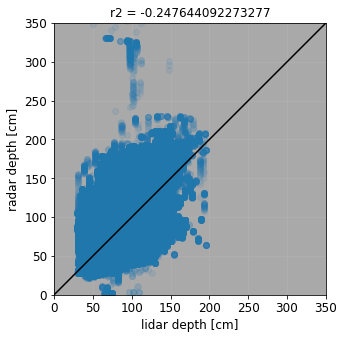

4.0 -2.0
extracting lidar data...
calculating r^2...


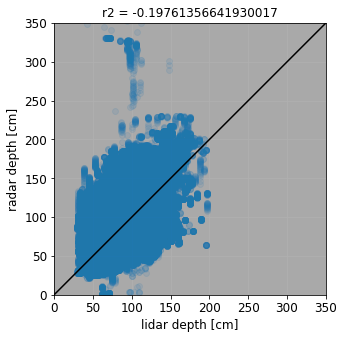

4.0 -1.5
extracting lidar data...
calculating r^2...


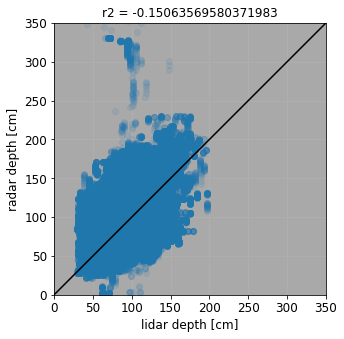

4.0 -1.0
extracting lidar data...
calculating r^2...


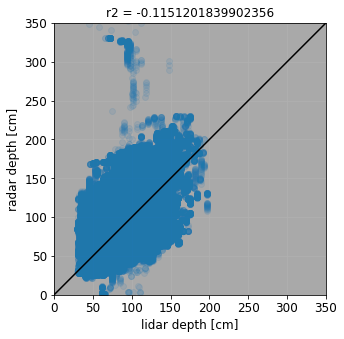

4.0 -0.5
extracting lidar data...
calculating r^2...


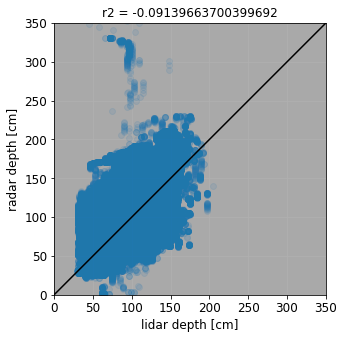

4.0 0.0
extracting lidar data...
calculating r^2...


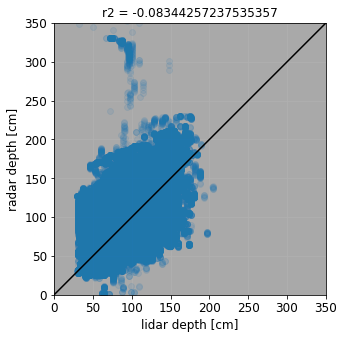

4.0 0.5
extracting lidar data...
calculating r^2...


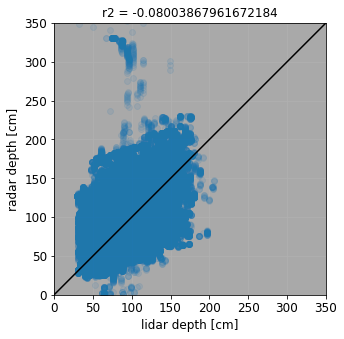

4.0 1.0
extracting lidar data...
calculating r^2...


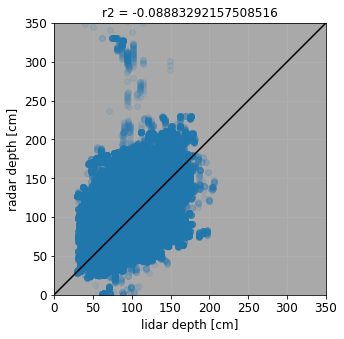

4.0 1.5
extracting lidar data...
calculating r^2...


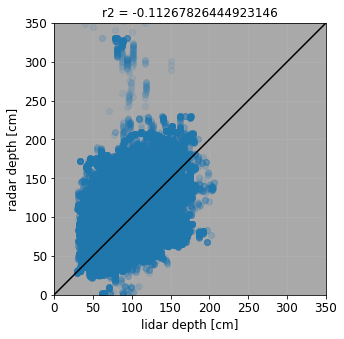

4.0 2.0
extracting lidar data...
calculating r^2...


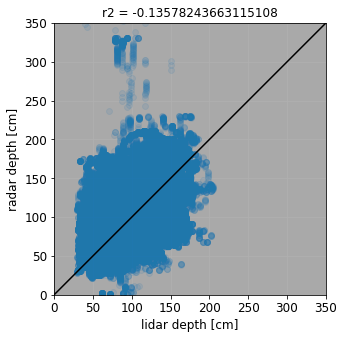

4.0 2.5
extracting lidar data...
calculating r^2...


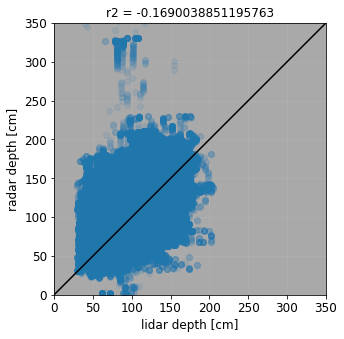

4.0 3.0
extracting lidar data...
calculating r^2...


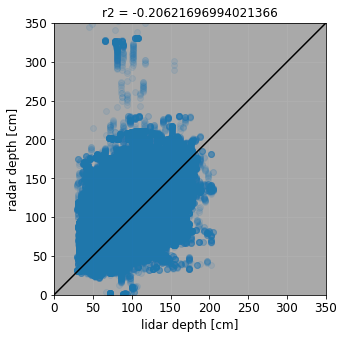

4.0 3.5
extracting lidar data...
calculating r^2...


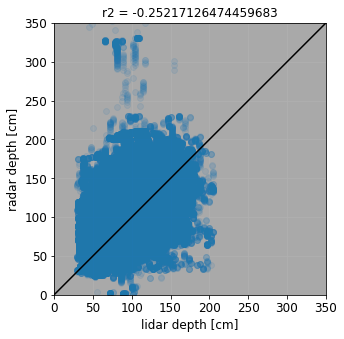

4.5 -3.0
extracting lidar data...


KeyboardInterrupt: 

In [265]:
step=0.5
x_shifts = []; y_shifts = []; R2s = []
for x_shift in np.arange(3.5,6,step):
    for y_shift in np.arange(-3,4,step):
        print(x_shift, y_shift)
        
        # shift location
        shifted_df = all_filtered_noNans[all_filtered_noNans.lidar_depth > 0] # grab non 0 lidar depths
        shifted_df.x = np.array(shifted_df.x)+x_shift # shift the x
        shifted_df.y = np.array(shifted_df.y)+y_shift # shift the y
        
        # re-extract the lidar data 
        print('extracting lidar data...')
        # ADD IN RANGE OF ARM LENGTHS TO TEST
        x_idxs = []; y_idxs = []; lidar_depths = []
        arm_length = 1.5 # consider arm_length [meters] on radar (set to 0 if none)
        for i in range(0, len(shifted_df.x)):
            x0 = shifted_df.x[i]; y0 = shifted_df.y[i]
            if i+1 < len(shifted_df):
                x1 = shifted_df.iloc[i+1].x; y1 = shifted_df.iloc[i+1].y # grab next point
                x = x1-x0; y = y1-y0 # calculate distance between points

                angle0 = np.degrees(np.arctan2(y,x)) # calculate angle between current and next point
                angle_arm = angle0 - 90 # calculate the angle to the arm, 90 degrees to the right (-90)
                if angle_arm <= -180: # reset to north direction if angle is less than -180
                    angle_arm = angle_arm + 360
            # Calculate the arm location using the angle_arm
            dx = arm_length * np.cos(np.radians(angle_arm))
            dy = arm_length * np.sin(np.radians(angle_arm))
            x_arm = x0 + dx; y_arm = y0 + dy

            # 1st pass, remove them out of bounds
            if x_arm < file.bounds.left or x_arm > file.bounds.right:
                lidar_depth = np.NaN
            elif y_arm < file.bounds.bottom or y_arm > file.bounds.top:
                lidar_depth = np.NaN
            else: # if in bounds, grab the nearest x and nearest y to the radar pt
                x_mindist = np.min(np.abs(grid_X-x_arm)); y_mindist = np.min(np.abs(grid_Y-y_arm))
                if x_mindist >= 0.5 or y_mindist >= 0.5: # if outside of grid cell (> 0.5 m from the grid center)
                    lidar_depth = np.NaN # failsafe!
                else: # if within grid cell, grab the lidar snow depth
                    x_idx = np.argmin(np.abs(grid_X-x_arm)); y_idx = np.argmin(np.abs(grid_Y-y_arm))
                    lidar_depth = lidar_DATA[y_idx-1,x_idx-1] # grab from raster
            lidar_depths.append(lidar_depth) # add to list
        shifted_df['lidar_depths'] = lidar_depths # add into dataframe
        shifted_df = shifted_df[shifted_df.lidar_depths > 0] # only keep > 0 depth

        # calculate the r^2
        print('calculating r^2...')
        radar_depths = np.array(shifted_df.radar_depth_cm)
        lidar_depths = np.array(shifted_df.lidar_depths)
        ss_res = np.nansum((lidar_depths - radar_depths)**2) # Sum of squares of residuals
        ss_tot = np.nansum((lidar_depths - np.nanmean(lidar_depths))**2) # Total sum of squares
        r2 = 1 - (ss_res / ss_tot)
#         r2_scikit = r2_score(lidar_depths, radar_depths)
#         print(r2, r2_scikit)
        
        # 1 to 1 plot
        minval=0; fs=12; fig, ax2 = plt.subplots(figsize=(5,5))
        ax2.plot(lidar_depths, radar_depths, 'o', alpha=a,label=window) # points
        ax2.plot([minval,maxval],[minval,maxval],'k-') # 1 to 1 line
        ax2.set_title(str(window)+' m window',fontsize=fs) # plot title
        plt.gca().set_aspect('equal'); ax2.grid(); ax2.set_facecolor('darkgrey')
        ax2.set_xlim(minval,maxval); ax2.set_ylim(minval,maxval); ax2.tick_params(labelsize=fs)
        ax2.set_xlabel('lidar depth [cm]', fontsize=fs); ax2.set_ylabel('radar depth [cm]', fontsize=fs)
        ax2.set_title('r2 = '+str(r2),fontsize=fs);plt.show()
        
        # store result
        R2s.append(r2); x_shifts.append(x_shift); y_shifts.append(y_shift)

In [266]:
new_df = pd.DataFrame(list(zip(x_shifts, y_shifts, R2s)), columns=['x_shift','y_shift','R2'])

In [269]:
combined_df = pd.concat([new_df, offset_df])
combined_df.sort_values(by='R2')

,x_shift,y_shift,R2
13,-3.0,3.5,-0.458305
27,-2.5,3.5,-0.440154
12,-3.0,3.0,-0.426290
41,-2.0,3.5,-0.418777
0,-3.0,-3.0,-0.416680
...,...,...,...
188,3.5,0.0,-0.073879
175,3.0,0.5,-0.072829
174,3.0,0.0,-0.072718
189,3.5,0.5,-0.072059


In [217]:
# offset_df = pd.DataFrame(list(zip(x_shifts, y_shifts, R2s)), columns=['x_shift','y_shift','R2'])
offset_df.sort_values(by='R2')

,x_shift,y_shift,R2
13,-3.0,3.5,-0.458305
27,-2.5,3.5,-0.440154
12,-3.0,3.0,-0.426290
41,-2.0,3.5,-0.418777
0,-3.0,-3.0,-0.416680
...,...,...,...
173,3.0,-0.5,-0.075648
188,3.5,0.0,-0.073879
175,3.0,0.5,-0.072829
174,3.0,0.0,-0.072718


In [218]:
offset_df.to_csv(radaroutpath+'geolocation_offset_r2.csv')

In [270]:
offset_df = combined_df

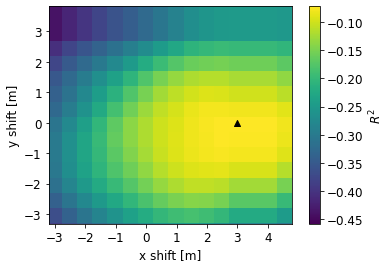

In [278]:
fs=12
plt.scatter(offset_df.x_shift, offset_df.y_shift,marker='s',s=2200,c=offset_df['R2'])
plt.gca().set_aspect('equal'); plt.tick_params(labelsize=fs)
cbar = plt.colorbar(); cbar.set_label('$R^2$',fontsize=fs); cbar.ax.tick_params(labelsize=fs)
plt.xlim(-3.2,4.8); plt.xticks([-3,-2,-1,0,1,2,3,4,])
plt.scatter(3.0,0.0,marker='^',color='black') # best parameter
plt.xlabel('x shift [m]',fontsize=fs); plt.ylabel('y shift [m]',fontsize=fs)
plt.show()

In [176]:
# plot a gridded image of shift and R2
shifted_df.radar_depth_cm

# calcualte RMSE before and RMSE after

0          85.196406
1          85.444219
2          85.568125
3          85.692031
4          85.939844
             ...    
4261267    91.558179
4261268    91.682159
4261269    91.682159
4261270    91.682159
4261271    91.558179
Name: radar_depth_cm, Length: 4261272, dtype: float64

In [215]:
# from sklearn.metrics import r2_score

In [216]:
# radar_depths = np.array(shifted_df.radar_depth_cm)
# lidar_depths = np.array(shifted_df.lidar_depths)
# r2 = r2_score(lidar_depths, radar_depths)
# print(f"R-squared: {r2:.4f}")